In [1]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [2]:
x.requires_grad_(True) #要追踪x的梯度
x.grad

In [3]:
y = 2*torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [4]:
y.backward() #请计算 y 对每一个输入变量的偏导数，并把结果存到它们的 .grad 里
x.grad

tensor([ 0.,  4.,  8., 12.])

In [5]:
x.grad == 4*x

tensor([True, True, True, True])

In [6]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_() # 清除之前的值
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

In [7]:
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度。
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x
# 等价于y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [8]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [9]:
%matplotlib inline
import random
from d2l import torch as d2l
def synthetic_data(w, b, num_examples):
    """生成y = Xw + b + 噪声。"""
    x = torch.normal(0, 1, (num_examples, len(w))) #生成形状为(num_examples, len(w))且服从正态分布，均值为0，标准差为1的张量
    y = torch.matmul(x, w) + b #矩阵乘法
    y += torch.normal(0, 0.01, y.shape)
    return x, y.reshape((-1, 1)) #列向量

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [10]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.0530,  0.6744]) 
label: tensor([1.7932])


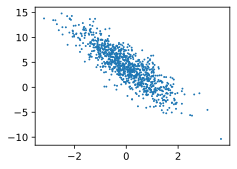

In [11]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [12]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples)) #[0, 1, 2,...,num_examples-1]
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices) # 随机打乱indices
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices] # 函数暂停，返回当前批次的数据
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break


tensor([[ 2.1487,  0.9103],
        [ 1.4426, -0.3507],
        [ 0.2674,  1.7130],
        [ 0.1974, -0.3847],
        [-1.0768, -1.1253],
        [-0.4491, -0.0943],
        [ 0.2747, -0.5969],
        [-1.0219, -0.8575],
        [-0.2546, -2.4648],
        [-1.2078, -1.0858]]) 
 tensor([[ 5.4058],
        [ 8.2665],
        [-1.1013],
        [ 5.9017],
        [ 5.8767],
        [ 3.6241],
        [ 6.7967],
        [ 5.0872],
        [12.0421],
        [ 5.4837]])


In [13]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [14]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [15]:
def squared_loss(y_hat, y):
    """均方误差"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [ ]:
# 梯度为正说明参数需要减小，梯度为负说明参数需要增大
def sgd(params, lr, batch_size):
    """
    实现小批量随机梯度下降(Stochastic Gradient Descent)优化算法
    
    参数说明：
    params: 模型参数列表，通常包含权重和偏置等需要更新的参数
    lr: 学习率(learning rate)，控制参数更新的步长大小
    batch_size: 批量大小，用于归一化梯度
    """
    # 使用torch.no_grad()上下文管理器，临时禁用梯度计算
    # 这是因为参数更新操作不需要参与梯度计算，这样可以节省内存并加速计算
    with torch.no_grad():
        # 遍历所有需要更新的参数
        for param in params:
            # 参数更新公式：θ = θ - lr * (grad / batch_size)
            # param.grad 是当前参数的梯度值
            # 除以batch_size是为了归一化，因为梯度是整个批次的总和在PyTorch中，loss.backward()计算的是整个batch的loss总和对应的梯度 除以batch_size相当于求平均梯度，这样学习率的选择就与batch_size无关了
            param -= lr * param.grad / batch_size #沿着梯度方向更新参数
            # 将参数的梯度清零，避免梯度累积
            # 这是因为PyTorch默认会累积梯度，如果不清零，梯度会在每次反向传播时累加
            param.grad.zero_()

In [ ]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # 计算当前批次的损失，是一个向量，每个元素是一个样本的损失
        l.sum().backward() # 计算当前批次的损失对参数的梯度，是一个向量，每个元素是一个参数的梯度 backaward需要从一个标量开始，所以要对损失求和
        sgd([w, b], lr, batch_size) # 由于反向传播已经找到了loss下降最快的方向并且存在了对应的参数中，所以直接更新参数即可
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')


epoch 1, loss 0.048059
epoch 2, loss 0.000210
epoch 3, loss 0.000050


In [ ]:
# 线性回归的简洁实现
import numpy as np
from torch.utils import data
from d2l import torch as d2l
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)


In [ ]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))


In [ ]:
from torch import nn
net = nn.Sequential(nn.Linear(2, 1))
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)


In [ ]:
loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [ ]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {float(l.mean()):f}')